# Marine Heatwaves — The 2013–2016 Northeast Pacific Marine Heatwave

This notebook uses gridded SST, wind stress, and Argo RG09 climatology products to investigate the 2013–2016 NE Pacific Marine Heatwave (the 2013–2016 NEP MHW), characterising its surface signature, mixed-layer shoaling, and upper-ocean heat-content anomalies.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

**How to cite:** If you use this notebook, please cite Sala, J., Giglio, D., Mills, K., & Scanderbeg, M. (2026). *argovis/demo_notebooks* (v0.1.0) [Software]. Zenodo. [https://doi.org/10.5281/zenodo.22032966](https://doi.org/10.5281/zenodo.22032966)

## Notebook structure

This notebook is divided into two parts. In the first part, data are queried from the Argovis API and a series of diagnostic plots are produced. In the second part (Student Work), you are asked to interpret those plots by answering a set of guided questions.

## Learning Goals

By the end of this activity, you will be able to:

1. **Describe the surface signature** of a marine heatwave — where extreme SST anomalies are detected and how they evolve over time.
2. **Relate extreme SST anomalies to subsurface changes** — how mixed-layer depth and upper-ocean heat content respond during the MHW event
3. **Interpret depth–time (Hovmöller) diagrams** — read temperature, salinity, density, and N² fields to identify anomalies propagating through the water column.
4. **Apply deseasonalisation and detrending** to isolate the MHW signal from the seasonal cycle and long-term trend.
5. **Connect observations to dynamics** — link the physical variables (MLD, OHC, N²) to the oceanic and atmospheric drivers of the event.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ───────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import numpy as np
import xarray as xr
import gsw
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APIKEY  = 'guest'   # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `tidy_grid` — sorts every spatial/temporal dimension of a gridded field so it's monotonic-increasing, and un-wraps longitude for boxes that cross the antimeridian. Needed because the API can return coordinates out of order, and a box crossing 180° comes back split into a negative and a positive branch — without this, `.sel(slice(...))`, `.interp`, and `contourf` can silently misbehave or show a broken/discontinuous longitude axis.
- `spatial_average` — *input: a gridded field.* Cos-latitude-weighted mean over a latitude band. `lat_band` is the actual `(lat_min, lat_max)` range of values to average over; `lat_dim` is just the *name* of the latitude coordinate in `da` (default `'latitude'`) — it lets the function work even if a dataset happens to label that coordinate differently, and is unrelated to the range itself. `lon_dim` plays the same "coordinate name" role for longitude (default `None`, meaning don't touch longitude). Only a latitude *range* can be specified — there is no equivalent `lon_band` argument. If `lon_dim` is provided, longitude is also fully collapsed to a scalar time series; otherwise longitude is left at its full queried resolution and only latitude is collapsed (Hovmöller output) — it does not average over longitude in that case.
- `remove_seasonal_cycle` — subtract the monthly climatology from a time series (or gridded time × space field) to produce an anomaly, keeping the trend; optionally smoothed with a centred running-mean via `smooth_window`
- `linear_detrend` — remove a least-squares linear trend, NaN-safe
- `deseason_detrend` — combined deseasonalisation + linear detrending
- `wind_speed_to_stress` — convert scalar wind speed to wind-stress magnitude
- `compute_ohc_profile` — **vertical integral on the fly**: upper-ocean heat content (0–depth_max) from gridded T/S
- `derive_TS_grid` — compute absolute salinity, conservative temperature, and σ₀ from gridded T/S via TEOS-10
- `mld_timeseries` — MLD time series from a (time × level) σ₀ field
- `n2_timeseries` — N² (time × level_mid) from gridded SA/CT via gsw.Nsquared
- `plot_surface_timeseries` — two-row figure (total + deseason./detrended anomaly) for one or more area-mean time series
- `plot_sst_evolution_maps` — SST snapshot maps at selected dates with box overlay
- `plot_depth_time_hovmoller` — depth–time Hovmöller panels (total + anomaly)

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions import traverse_query
from notebook_helpers.functions_SLA import tidy_grid
from notebook_helpers.functions_candidates_for_functions import spatial_average, remove_seasonal_cycle
from notebook_helpers.functions_MHW import (
    linear_detrend, deseason_detrend, wind_speed_to_stress, compute_ohc_profile,
    derive_TS_grid, mld_timeseries, n2_timeseries,
    plot_surface_timeseries, plot_sst_evolution_maps, plot_depth_time_hovmoller,
)

## Setup: configuration

**First run: do not modify anything in this cell.** Run it as-is to query a 10-year record (2010–2020) that spans the pre-event baseline, the 2013–2016 NEP MHW, and the post-event recovery. The monthly climatology used for deseasonalisation is estimated from this full 10-year window, providing a more robust baseline than the event period alone. Query times depend on box size: the full averaging region (19° × 16°) takes ~6 min; the full SST map domain (70° × 40°) takes ~8 min. The default boxes below are reduced to ~1/3 the area of the full domains.

> **Note on region size:** The default averaging boxes are set to ~1/3 of the full domain area to keep query times manageable. If you are interested in exploring the full domains (averaging region ~6 min, SST map domain ~8 min) or an alternate box of your choice based on the SST maps, you can uncomment the corresponding lines in the configuration cell — this is not required to complete the activity questions.

> **Student Work (end of notebook):** Work through the notebook in order, then turn to the discussion questions at the end. The optional extended analysis (Q9–Q10) invites you to try a shorter time window and examine how the results change.

In [3]:
# MODIFY HERE
# ── Averaging region — reduced (~1/3 area of full box) ────────────────────────
LAT_BAND = (39.0, 48.0)
LON_BAND = (-150.5, -139.5)
BOX_AVG  = [[LON_BAND[0], LAT_BAND[0]], [LON_BAND[1], LAT_BAND[1]]]

# ── Averaging region — FULL box (35.5–51.5 N, 154.5–135.5 W, ~6 min) ─────────
# LAT_BAND = (35.5, 51.5)
# LON_BAND = (-154.5, -135.5)
# BOX_AVG  = [[LON_BAND[0], LAT_BAND[0]], [LON_BAND[1], LAT_BAND[1]]]

# ── Averaging region — SMALL test box (fast query) ────────────────────────────
# LAT_BAND = (42.5, 44.5)
# LON_BAND = (-146.5, -144.5)
# BOX_AVG  = [[LON_BAND[0], LAT_BAND[0]], [LON_BAND[1], LAT_BAND[1]]]

# ── SST map box — reduced (~1/3 area of full NE Pacific domain) ──────────────
BOX_MAP  = [[-165, 28.5], [-125, 51.5]]

# ── SST map box — FULL NE Pacific (180–110 W, 20–60 N, ~8 min) ──────────────
# BOX_MAP  = [[-180, 20], [-110, 60]]

# ── Time period: 10-year window spanning the 2013–2016 NEP MHW ───────────────
time_period = {'startDate': '2010-01-01T00:00:00Z', 'endDate': '2020-01-01T00:00:00Z'}

# ── Depth / OHC / MLD settings ────────────────────────────────────────────────
YLIM       = [0, 300]
OHC_DEPTH  = 300
MLD_THRESH = 0.03
MLD_REF    = 10

# ── built on the fly (do not modify) ──────────────────────────────────────────
LON0, LAT0   = np.mean(LON_BAND), np.mean(LAT_BAND)
regions      = [{"box": BOX_AVG}]
regions_map  = [{"box": BOX_MAP}]
time_periods = [time_period]

grids = {
    'timeseries/noaasst':  'sst',
    'timeseries/ccmpwind': 'ws',
    'grids/rg09':          'rg09_temperature,rg09_salinity',
}
grid_sst = {'timeseries/noaasst': 'sst'}

span = np.datetime64(time_period["endDate"][:10]) - np.datetime64(time_period["startDate"][:10])
if span < np.timedelta64(365*3, "D"):
    print('Time period < 3 years: monthly climatology will be poorly sampled.')

### Step 1 — Query gridded products on the averaging box

In [4]:
# ── Step 1: Query gridded products on the averaging box — run, do not modify ──
grid_results = traverse_query(regions, time_periods, grids, avh.queryGrid, APIKEY, APIROOT)

print('Queried:', list(grid_results))

Queried: ['timeseries/noaasst', 'timeseries/ccmpwind', 'grids/rg09']


### Step 2 — Query SST on the map box (for evolution maps)

In [5]:
# ── Step 2: Query SST on the larger map box — run, do not modify ─────────────
sst_map_results = traverse_query(regions_map, time_periods, grid_sst, avh.queryGrid, APIKEY, APIROOT)

print('Queried SST map box')

The temporospatial extent of your request is enormous! If you are using the query helper, it will now try to slice this request up for you. Try setting verbose=true to see how it is slicing this up.
Queried SST map box


## Visualization — SST evolution maps

The maps below show how the **deseasonalised and detrended SST anomaly** evolved across the NE Pacific before, during, and after the 2013–2016 NEP MHW. Anomalies are computed by subtracting the monthly climatology and linear trend estimated from the full queried period (2010–2020). The black rectangle marks the averaging box used for the time-series analysis below.

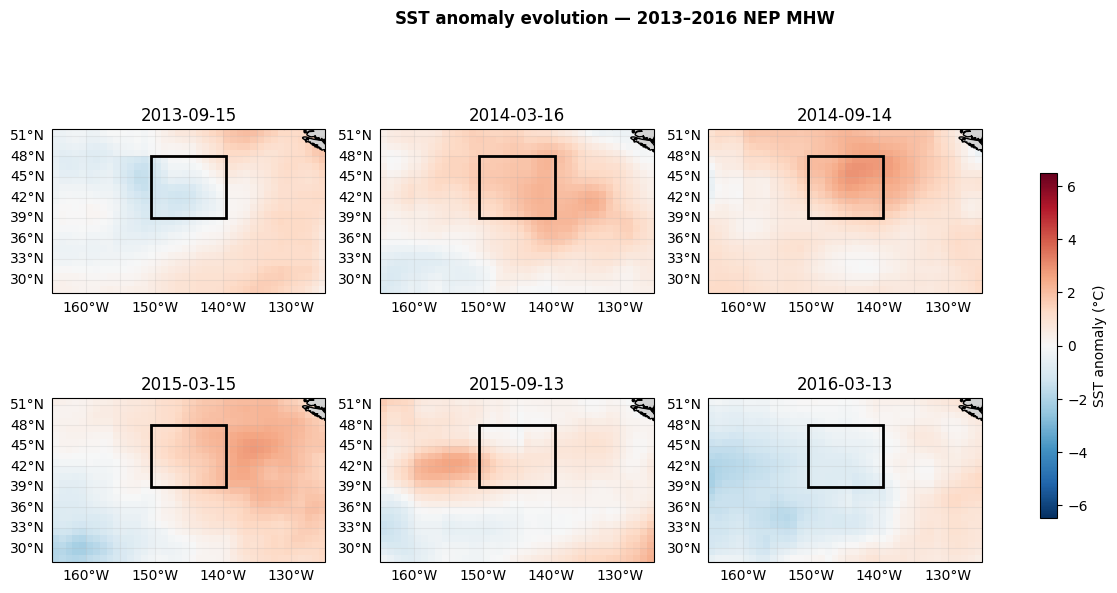

In [6]:
# MODIFY HERE — dates capturing the MHW evolution (pre / onset / peak / decay)
map_dates = ['2013-09-15', '2014-03-15', '2014-09-15', '2015-03-15', '2015-09-15', '2016-03-15']

# ── SST anomaly evolution maps — run after editing dates above ───────────────
sst_map      = tidy_grid(sst_map_results['timeseries/noaasst'][0][0].sst.squeeze('level'))
sst_map_anom = deseason_detrend(sst_map)
plot_sst_evolution_maps(
    sst_map_anom, map_dates, LAT_BAND, LON_BAND,
    title='SST anomaly evolution — 2013–2016 NEP MHW',
    cmap='RdBu_r', cbar_label='SST anomaly (°C)', symmetric_cbar=True,
)

## Visualization — Area-mean surface time series

The top row shows the **total** signal for SST, wind-stress magnitude, mixed-layer depth, and upper-ocean heat content (0–300 m). The bottom row shows the **deseasonalised and linearly-detrended anomaly**, which isolates the MHW signal from the seasonal cycle and any long-term trend.

> **Note on deseasonalisation:** the monthly climatology is estimated from the full queried time window (2010–2020). This 10-year baseline includes pre- and post-event years, producing more robust anomalies than a climatology computed from the event period alone.

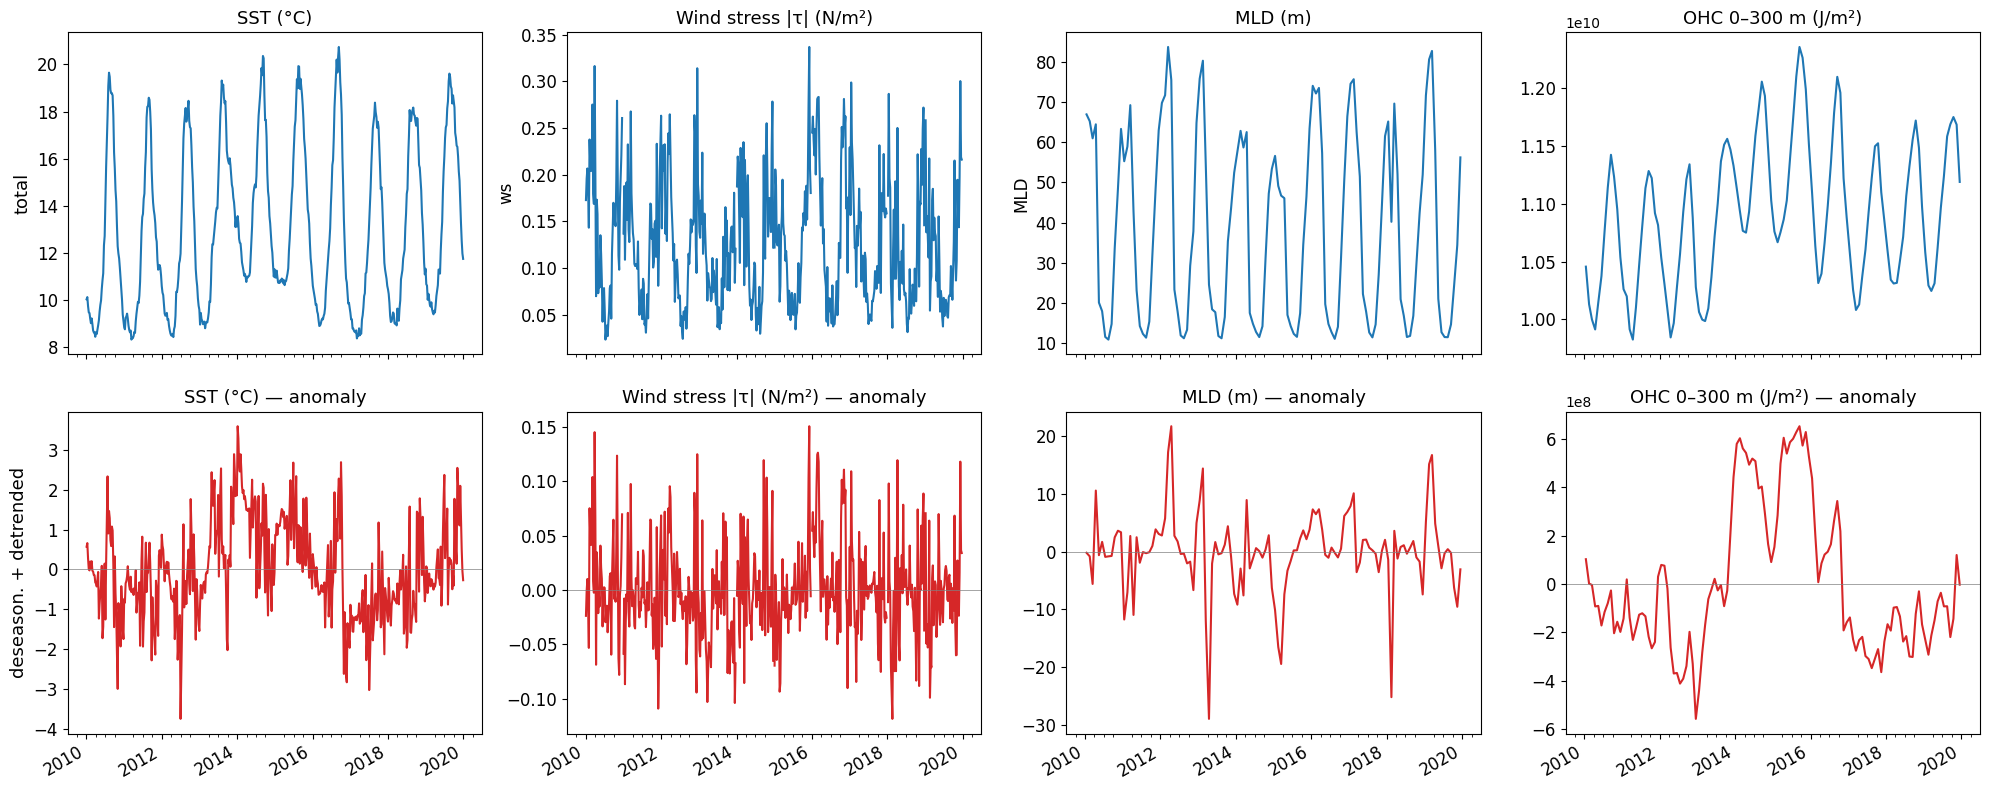

In [7]:
# ── Step 3: area-mean surface time series — run, do not modify ───────────────
# SST: sub-select the averaging box from the larger SST grid
sst_avg = sst_map.sel(latitude=slice(*LAT_BAND), longitude=slice(*LON_BAND))
sst_ts  = spatial_average(sst_avg, LAT_BAND, lon_dim='longitude')

# Wind: scalar speed → stress magnitude, then area-mean
ws       = tidy_grid(grid_results['timeseries/ccmpwind'][0][0].ws.squeeze('level'))
tau      = wind_speed_to_stress(ws)
tau_ts   = spatial_average(tau, LAT_BAND, lon_dim='longitude')

# RG: area-mean T/S profile → derived fields → MLD and OHC
temp_rg = tidy_grid(grid_results['grids/rg09'][0][0].rg09_temperature)
salt_rg = tidy_grid(grid_results['grids/rg09'][0][0].rg09_salinity)
T_prof  = spatial_average(temp_rg, LAT_BAND, lon_dim='longitude')   # time × level
S_prof  = spatial_average(salt_rg, LAT_BAND, lon_dim='longitude')
SA, CT, SIG0 = derive_TS_grid(T_prof, S_prof, LON0, LAT0)
mld_ts  = mld_timeseries(SIG0, threshold_delta=MLD_THRESH, reference_pressure=MLD_REF)
ohc_ts  = compute_ohc_profile(CT, SIG0, depth_max=OHC_DEPTH)

series = {
    'SST (°C)':                 sst_ts,
    'Wind stress |τ| (N/m²)':   tau_ts,
    'MLD (m)':                  mld_ts,
    f'OHC 0–{OHC_DEPTH} m (J/m²)': ohc_ts,
}

# ── Surface time series — run after Step 3 ──────────────────────────────────
plot_surface_timeseries(series)


## Visualization — Area-mean Depth–time fields (Hovmöller)

Each row shows one field (conservative temperature, absolute salinity, potential density σ₀, N²) as a function of time (x-axis) and depth (y-axis). Left: total field. Right: deseasonalised and detrended anomaly. The black line overlaid on the upper three panels marks the mixed-layer depth.

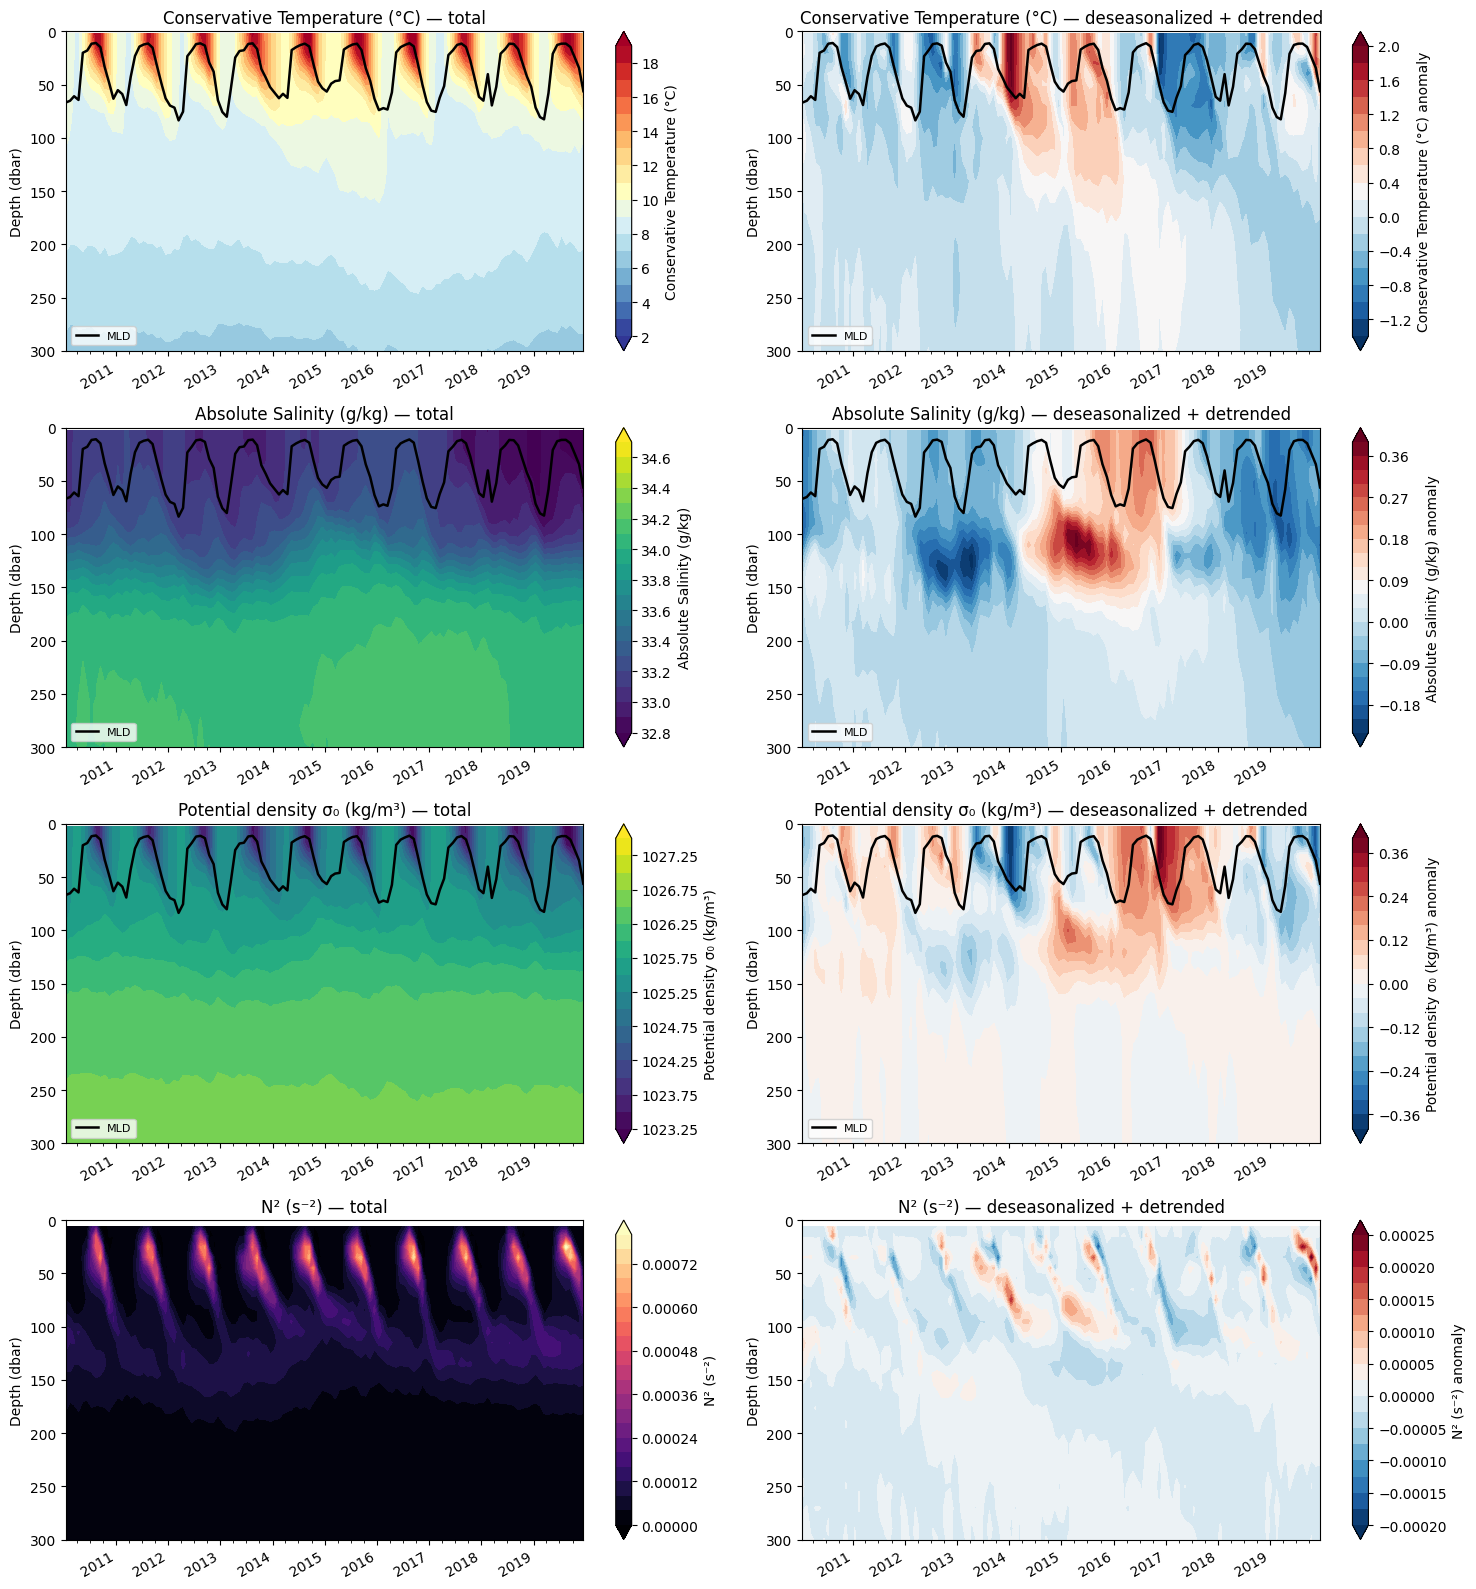

In [8]:
# ── Step 4: RG depth–time fields, total + anomaly, with MLD overlaid — run only ─
fields = [
    ('Conservative Temperature (°C)', CT,                          'level',     'RdYlBu_r'),
    ('Absolute Salinity (g/kg)',       SA,                          'level',     'viridis'),
    ('Potential density σ₀ (kg/m³)',   SIG0,                        'level',     'viridis'),
    ('N² (s⁻²)',                       n2_timeseries(SA, CT, LAT0), 'level_mid', 'magma'),
]
plot_depth_time_hovmoller(fields, mld_ts, ylim=(YLIM[1], YLIM[0]))

## ✏️ Student Work — Question 1: Surface Signature

Look at the SST evolution maps and the SST time series.

1. When did the 2013–2016 NEP MHW begin and peak? How long did the warm anomaly persist?
2. What was the approximate magnitude of the peak SST anomaly (°C) in your averaging box?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 2: Wind Forcing

Compare the wind-stress anomaly with the SST anomaly.

Is the wind-stress anomaly positive or negative during the peak of the 2013–2016 NEP MHW? What does reduced (or strengthened) wind stress imply for ocean heat exchange?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 3: Mixed Layer and Heat Content

1. How does MLD change during the event? Does the mixed layer shoal or deepen?
2. How does OHC change? Is the surface warming accompanied by an increase or decrease in upper-ocean heat content?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 4: Subsurface Structure (Hovmöller)

1. In the temperature Hovmöller, at what depth is the warm anomaly strongest? Does it appear confined near the surface or does it extend deeper?
2. How do the salinity and density anomalies compare to the temperature anomaly?
3. How does N² change during the 2013–2016 NEP MHW? What does this imply for vertical mixing?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 5: Extended Analysis (Optional)

> **📄 Before you continue:** Save a record of your work so far now (e.g. **File → Print Preview**, or **File → Save and Export Notebook As → PDF/HTML**). Re-running the configuration cell with a new time period will overwrite the plots and time series above, so this is your only chance to keep a copy of the 10-year-window results.

Go back to the **Setup: configuration** cell and change the time period to a shorter 3-year window centred on the event (e.g. 2013–2016), then re-run all cells.

1. How do the time series and Hovmöller diagrams change with a 3-year window compared to the 10-year record?
2. Does the magnitude or timing of the anomalies differ? What does this tell you about the importance of the baseline period for deseasonalisation?

*Double-click to edit this cell and write your answer.*